# Comparing TF old models vs the onnx models for the WLTC cycle 

In [1]:
from ONNX_Predict.LSTM_onnx import LSTM_onnx 
from ONNX_Predict.Scaler_onnx import Scaler_onnx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import tensorflow as tf

2026-02-09 16:02:10.472054: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-09 16:02:12.512343: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-09 16:02:12.517681: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-09 16:02:12.793058: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-09 16:02:13.650468: I tensorflow/core/platform/cpu_feature_guar

### Paths

In [2]:
ONNX_ICE_DIR = os.path.join(
    "controller_for_ICE_PG", "SHARE", "CTTC_models", "ONNX", "ICE"
)
ONNX_PG_DIR = os.path.join(
    "controller_for_ICE_PG", "SHARE", "CTTC_models", "ONNX", "PG"
)

OLD_ICE_DIR = os.path.join("controller_for_ICE_PG", "src", "models_markus", "ICE_Model_Update_01")
OLD_ICE_DIR = os.path.join("controller_for_ICE_PG", "src", "models_markus", "PG_Model_M1.1_without_EM1_Torque")

CSV_PATH = os.path.join("internal_lstm_models", "Test_Cycles", "WLTC.csv")

### Loading ICE and PG onnx models into memory

In [3]:
onnx_ice_scaler_in = Scaler_onnx("scaler_input.onnx", ONNX_ICE_DIR)
onnx_ice_scaler_out = Scaler_onnx("scaler_output.onnx", ONNX_ICE_DIR)
onnx_ice_scaler_inverse_out = Scaler_onnx("scaler_inverse_output.onnx", ONNX_ICE_DIR)
ice_onnx = LSTM_onnx("ICE_onnx.onnx", ONNX_ICE_DIR, "model.h5")

2026-02-09 16:02:27.409326595 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3393033, index: 4, mask: {5, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-02-09 16:02:27.409341923 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3393037, index: 8, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-02-09 16:02:27.409323780 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3393032, index: 3, mask: {4, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-02-09 16:02:27.409335662 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3393034, index: 5, mask: {6, }, error code: 22 error msg: Invalid argument. Specify the n

In [4]:
onnx_pg_scaler_in = Scaler_onnx("scaler_input.onnx", ONNX_PG_DIR)
onnx_pg_scaler_out = Scaler_onnx("scaler_output.onnx", ONNX_PG_DIR)
onnx_pg_scaler_inverse_out = Scaler_onnx("scaler_inverse_output.onnx", ONNX_PG_DIR)
pg_onnx = LSTM_onnx("PG_onnx.onnx", ONNX_PG_DIR, "model.h5")

2026-02-09 16:02:31.259294076 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3393084, index: 2, mask: {3, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-02-09 16:02:31.259332968 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3393086, index: 4, mask: {5, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-02-09 16:02:31.259314614 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3393085, index: 3, mask: {4, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-02-09 16:02:31.278901168 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3393092, index: 10, mask: {11, }, error code: 22 error msg: Invalid argument. Specify the

In [5]:
# Helper to find columns loosely (like Modular_NN)
def get_col(df, name):
    if name in df.columns:
        return df[name].values
    for c in df.columns:
        if c.split("(")[0].strip() == name:
            return df[c].values
    raise KeyError(f"Column '{name}' not found in CSV")

In [6]:
df = pd.read_csv(CSV_PATH, sep=";")

ice_speed = get_col(df, "ICE_Speed_rpm")  # ice and pg
fuel = get_col(df, "fuel_mg")  # ice
t_amb = get_col(df, "T_amb_K")  # ice
p_amb = get_col(df, "p_amb_bar")  # ice
em2_torque = get_col(df, "EM2_Torque_Nm")  # pg
brake = get_col(df, "Brake_perc")  # pg

input_ice = np.column_stack([ice_speed, fuel, t_amb, p_amb])
input_pg = np.column_stack(
    [ice_speed, em2_torque, brake]
)  # ice torque missing because will be predicted from ice

In [7]:
print(input_ice.shape)

(3601, 4)


### Reset State

In [8]:
ice_onnx.reset_states()

In [ ]:
x = input_ice[0,:].copy()
x = np.expand_dims(x, axis=0)  # Shape becomes (1, 4)
print(x.shape)

x = x.astype('float32')
print(x)

In [ ]:
x_scaled = onnx_ice_scaler_in.transform(x)
x_scaled = np.reshape(x_scaled, (1,1,4))

In [ ]:
y_initial = np.array([[0, 0, 0, 0, 0]], dtype='float32')
y_scaled_initial = onnx_ice_scaler_out.transform(y_initial)[0].reshape((1,1,5))

### ONNX Prediction

In [ ]:
y_scaled_predictions = []

In [ ]:
y_prediction_scaled = ice_onnx([x_scaled, y_scaled_initial])
y_scaled_predictions.append(y_prediction_scaled[0][0][0])
y_prediction_scaled

In [ ]:
print(y_scaled_predictions)

In [9]:
y_initial = np.array([[0, 0, 0, 0, 0]], dtype='float32')
y_scaled_initial = onnx_ice_scaler_out.transform(y_initial)[0].reshape((1,1,5))

y_scaled_predictions = []

# input_ice.shape[0] gives you 3601
for t in range(input_ice.shape[0]):
    # Extract the row
    row = input_ice[t].copy()  
    
    # Turns shape (4,) into (1, 4)
    current_input = row.reshape(1, -1)
    current_input = current_input.astype("float32")
    
    x_scaled = onnx_ice_scaler_in.transform(current_input)
    x_scaled = np.reshape(x_scaled, (1,1,4))
    
    y_prediction_scaled = ice_onnx([x_scaled, y_scaled_initial])
    y_scaled_predictions.append(y_prediction_scaled[0][0][0])

In [ ]:
print(y_scaled_predictions)

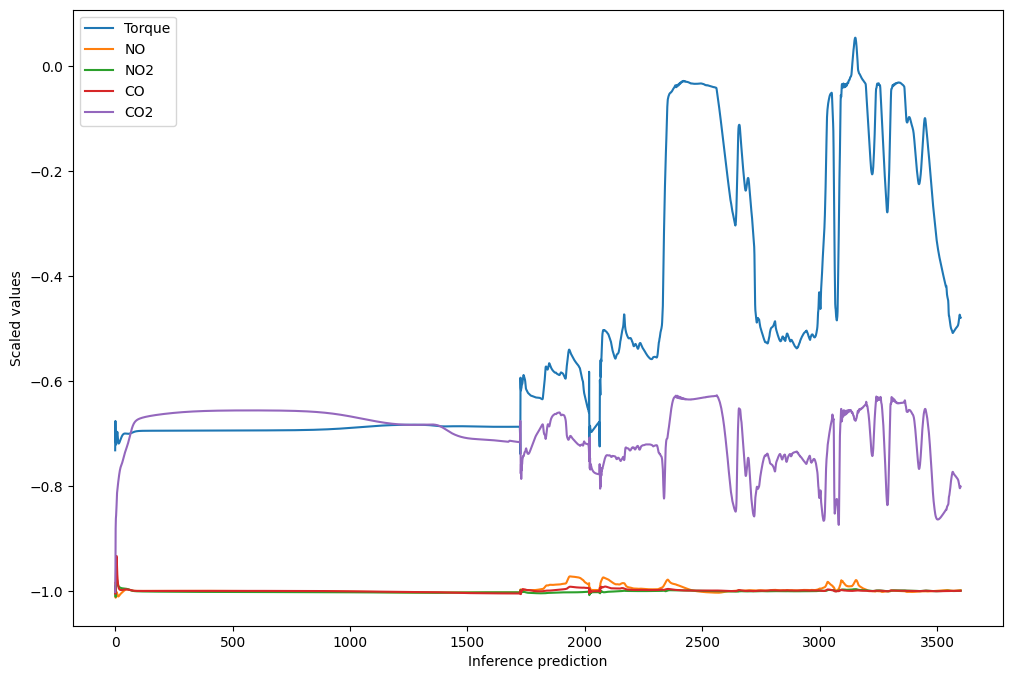

In [16]:
plot_data = np.array(y_scaled_predictions)
preds, plot_vars = plot_data.shape

labels = ['Torque', 'NO', 'NO2', 'CO', 'CO2']

_, ax = plt.subplots(figsize=(12,8))
for var in range(plot_vars):
    ax.plot(plot_data[:,var], label=labels[var])

ax.set_ylabel('Scaled values')
ax.set_xlabel('Inference prediction')
ax.legend()

plt.show()

In [13]:
%%timeit
ice_onnx([x_scaled, y_scaled_initial])

29.5 μs ± 35.3 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
